<a href="https://colab.research.google.com/github/vishwajeetAgrahari/IITJ/blob/NLU/Sans_Eng_Trans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchtext sentencepiece bert-score nltk pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import random
import math
import time

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from collections import Counter

from nltk.translate.bleu_score import corpus_bleu
from bert_score import score

from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [6]:
train_sa = pd.read_csv("train_sa_10000.csv")
train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")
dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")
test_en = pd.read_csv("test_en_1000.csv")

In [7]:
train = train_sa.merge(train_en, on="Source_id")
dev = dev_sa.merge(dev_en, on="Source_id")
test = test_sa.merge(test_en, on="Source_id")

train.head()

,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [8]:
def tokenize(text):
    return text.lower().split()

In [9]:
SPECIALS = ["<pad>","<sos>","<eos>","<unk>"]

def build_vocab(sentences):

    counter = Counter()

    for s in sentences:
        counter.update(tokenize(s))

    vocab = SPECIALS.copy()

    vocab += [w for w,c in counter.items() if c>=1]

    stoi = {w:i for i,w in enumerate(vocab)}
    itos = {i:w for w,i in stoi.items()}

    return stoi,itos

src_stoi, src_itos = build_vocab(train["Sentence_sa"])
trg_stoi, trg_itos = build_vocab(train["Sentence_en"])

In [10]:
class TranslationDataset(Dataset):

    def __init__(self,data):

        self.data=data

    def numericalize(self,text,vocab):

        ids=[vocab["<sos>"]]

        ids += [vocab.get(w,vocab["<unk>"]) for w in tokenize(text)]

        ids.append(vocab["<eos>"])

        return ids

    def __len__(self):

        return len(self.data)

    def __getitem__(self,idx):

        row=self.data.iloc[idx]

        src = self.numericalize(row["Sentence_sa"], src_stoi)
        trg = self.numericalize(row["Sentence_en"], trg_stoi)

        return torch.tensor(src),torch.tensor(trg)

In [11]:
def collate(batch):

    src,trg=zip(*batch)

    src=nn.utils.rnn.pad_sequence(src,batch_first=True,padding_value=0)

    trg=nn.utils.rnn.pad_sequence(trg,batch_first=True,padding_value=0)

    return src,trg

train_loader=DataLoader(
    TranslationDataset(train),
    batch_size=64,
    shuffle=True,
    collate_fn=collate
)

dev_loader=DataLoader(
    TranslationDataset(dev),
    batch_size=64,
    collate_fn=collate
)

In [12]:
class Encoder(nn.Module):

    def __init__(self,input_dim,emb_dim,hid_dim):

        super().__init__()

        self.embedding=nn.Embedding(input_dim,emb_dim,padding_idx=0)

        self.gru=nn.GRU(emb_dim,hid_dim,batch_first=True)

    def forward(self,x):

        emb=self.embedding(x)

        outputs,hidden=self.gru(emb)

        return outputs,hidden

In [13]:
class Attention(nn.Module):

    def __init__(self, hidden_size):
        super().__init__()

        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        # hidden: [1,B,H]
        # encoder_outputs: [B,S,H]

        batch_size = encoder_outputs.size(0)
        src_len = encoder_outputs.size(1)

        # [B,H]
        hidden = hidden.squeeze(0)

        # [B,S,H]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(
            self.attn(
                torch.cat((hidden, encoder_outputs), dim=2)
            )
        )

        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

In [14]:
class Decoder(nn.Module):

    def __init__(self,output_dim,emb_dim,hid_dim):

        super().__init__()

        self.embedding=nn.Embedding(output_dim,emb_dim,padding_idx=0)

        self.attention=Attention(hid_dim)

        self.gru=nn.GRU(emb_dim+hid_dim,hid_dim,batch_first=True)

        self.fc=nn.Linear(hid_dim*2,output_dim)

    def forward(self,input,hidden,encoder_outputs):

        input=input.unsqueeze(1)

        embedded=self.embedding(input)

        a = self.attention(hidden, encoder_outputs)

        a=a.unsqueeze(1)

        weighted=torch.bmm(a,encoder_outputs)

        rnn_input=torch.cat((embedded,weighted),2)

        output,hidden=self.gru(rnn_input,hidden)

        pred=self.fc(torch.cat((output.squeeze(1),weighted.squeeze(1)),1))

        return pred,hidden

In [15]:
class Seq2Seq(nn.Module):

    def __init__(self,encoder,decoder):

        super().__init__()

        self.encoder=encoder
        self.decoder=decoder

    def forward(self,src,trg,teacher=0.5):

        batch=src.shape[0]

        trg_len=trg.shape[1]

        vocab=len(trg_stoi)

        outputs=torch.zeros(batch,trg_len,vocab).to(device)

        enc_out,hidden=self.encoder(src)

        inp=trg[:,0]

        for t in range(1,trg_len):

            out,hidden=self.decoder(inp,hidden,enc_out)

            outputs[:,t]=out

            best=out.argmax(1)

            inp=trg[:,t] if random.random()<teacher else best

        return outputs

In [16]:
encoder=Encoder(len(src_stoi),256,512)

decoder=Decoder(len(trg_stoi),256,512)

model=Seq2Seq(encoder,decoder).to(device)

criterion=nn.CrossEntropyLoss(ignore_index=0)

optimizer=optim.Adam(model.parameters(),lr=0.001)

In [17]:
epochs = 15

train_losses = []
val_losses = []

for epoch in range(epochs):

    # -------------------- Training --------------------
    model.train()
    train_loss = 0

    for src, trg in train_loader:

        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg)

        output = output[:,1:].reshape(-1, len(trg_stoi))
        trg2 = trg[:,1:].reshape(-1)

        loss = criterion(output, trg2)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------- Validation --------------------
    model.eval()

    val_loss = 0

    with torch.no_grad():

        for src, trg in dev_loader:

            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher=0)

            output = output[:,1:].reshape(-1, len(trg_stoi))
            trg2 = trg[:,1:].reshape(-1)

            loss = criterion(output, trg2)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(dev_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Training Loss   : {avg_train_loss:.4f}")
    print(f"Validation Loss : {avg_val_loss:.4f}")

Epoch 1/15
Training Loss   : 6.9594
Validation Loss : 6.7659
Epoch 2/15
Training Loss   : 5.9389
Validation Loss : 6.6843
Epoch 3/15
Training Loss   : 5.0861
Validation Loss : 6.7412
Epoch 4/15
Training Loss   : 4.1203
Validation Loss : 6.9727
Epoch 5/15
Training Loss   : 3.2812
Validation Loss : 7.1102
Epoch 6/15
Training Loss   : 2.8355
Validation Loss : 7.2707
Epoch 7/15
Training Loss   : 2.5146
Validation Loss : 7.3922
Epoch 8/15
Training Loss   : 2.1989
Validation Loss : 7.5340
Epoch 9/15
Training Loss   : 1.8502
Validation Loss : 7.6579
Epoch 10/15
Training Loss   : 1.5992
Validation Loss : 7.8603
Epoch 11/15
Training Loss   : 1.3506
Validation Loss : 8.0345
Epoch 12/15
Training Loss   : 1.1087
Validation Loss : 8.1836
Epoch 13/15
Training Loss   : 0.9113
Validation Loss : 8.2993
Epoch 14/15
Training Loss   : 0.7432
Validation Loss : 8.4489
Epoch 15/15
Training Loss   : 0.6094
Validation Loss : 8.5499


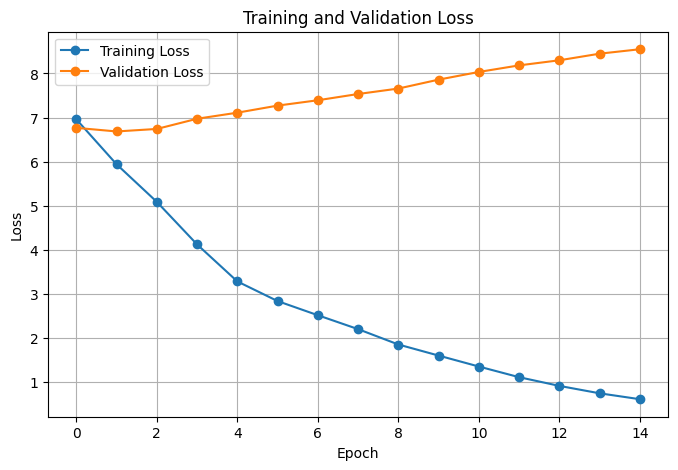

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def translate(sentence):

    model.eval()

    tokens=["<sos>"]+tokenize(sentence)+["<eos>"]

    ids=[src_stoi.get(x,3) for x in tokens]

    src=torch.tensor(ids).unsqueeze(0).to(device)

    enc_out,hidden=model.encoder(src)

    inp=torch.tensor([trg_stoi["<sos>"]]).to(device)

    result=[]

    for i in range(50):

        out,hidden=model.decoder(inp,hidden,enc_out)

        pred=out.argmax(1).item()

        if pred==trg_stoi["<eos>"]:
            break

        result.append(trg_itos[pred])

        inp=torch.tensor([pred]).to(device)

    return " ".join(result)

In [ ]:
predictions=[]

references=[]

for i,row in test.iterrows():

    pred=translate(row["Sentence_sa"])

    predictions.append(pred)

    references.append([tokenize(row["Sentence_en"])])

bleu=corpus_bleu(references,[tokenize(x) for x in predictions])

print("BLEU:",bleu)

P,R,F=score(
    predictions,
    list(test["Sentence_en"]),
    lang="en",
    rescale_with_baseline=True
)

print("BERTScore F1:",F.mean().item())

BLEU: 0.053879123854777076


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.11800440400838852


In [ ]:
start=time.time()

predictions=[]

for s in test["Sentence_sa"]:

    predictions.append(translate(s))

end=time.time()

print("Inference Time:",end-start,"seconds")

Inference Time: 23.47248077392578 seconds


In [ ]:
params=sum(p.numel() for p in model.parameters())

print("Total Parameters:",params)

Total Parameters: 34649568


In [ ]:
submission=pd.DataFrame({
    "Source id":test["Source_id"],
    "Sentence en":predictions
})

submission.to_csv("submission.csv",index=False,encoding="utf-8")

submission.head()

,Source id,Sentence en
0,1,and select the code as the code as shown.
1,2,a can be a by a file when his name of the shel...
2,3,i i will click on other for for a new account.
3,4,"and then here, by the variable a variable by d..."
4,5,and i have entered these have a the voice of t...
